In [20]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Dataset Overview

- **File**: `historical_data.csv`
- **Unit of analysis**: one row represents one delivery order.
- **Target variable**: total delivery duration in seconds, computed as:
  - start: `created_at`
  - end: `actual_delivery_time`
- **Time format**: timestamps are in UTC.
- **Value units**:
  - monetary values are in cents
  - duration values are in seconds

## Feature Groups

- **Time features**
  - `market_id`: identifier for city/region
  - `created_at`: order creation timestamp
  - `actual_delivery_time`: delivery completion timestamp

- **Store features**
  - `store_id`: restaurant identifier
  - `store_primary_category`: primary cuisine/category
  - `order_protocol`: order reception protocol identifier

- **Order features**
  - `total_items`: total items in the order
  - `subtotal`: order subtotal (cents)
  - `num_distinct_items`: number of unique items
  - `min_item_price`: minimum item price (cents)
  - `max_item_price`: maximum item price (cents)

- **Operational features (at `created_at`)**
  - `total_onshift_dashers`: available dashers nearby
  - `total_busy_dashers`: busy dashers nearby
  - `total_outstanding_orders`: active outstanding orders nearby

- **Model-based estimate features**
  - `estimated_order_place_duration`: estimated order placement duration (seconds)
  - `estimated_store_to_consumer_driving_duration`: estimated drive time (seconds)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [22]:
df = pd.read_csv('../data/raw/historical_data.csv')

In [23]:
# df = pd.read_csv('https://raw.githubusercontent.com/iamnitishsah/FoodOps.AI/refs/heads/main/DeliveryOps/data/raw/historical_data.csv')

In [24]:
len(df)
df.sample(10)

197428

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
154659,6.0,2015-02-18 02:45:24,2015-02-18 03:30:16,4360,pizza,3.0,1,1649,1,799,799,NaN,NaN,NaN,251,266.0
156114,5.0,2015-02-13 02:37:53,2015-02-13 03:28:35,1411,cafe,2.0,3,1507,2,419,669,116.0,91.0,157.0,251,807.0
114425,3.0,2015-02-02 02:02:00,2015-02-02 03:09:40,5548,burger,5.0,1,1050,1,600,600,14.0,14.0,23.0,251,130.0
73503,4.0,2015-01-29 19:23:30,2015-01-29 19:58:04,1383,hawaiian,3.0,3,2035,3,255,1095,8.0,6.0,10.0,251,659.0
30277,2.0,2015-01-27 01:27:37,2015-01-27 01:54:31,5542,american,1.0,2,2100,2,900,1200,58.0,78.0,64.0,446,236.0
146428,2.0,2015-01-24 01:33:03,2015-01-24 02:15:59,2506,pizza,1.0,2,3550,2,1075,2475,76.0,63.0,92.0,446,297.0
15377,6.0,2015-02-06 20:45:37,2015-02-06 21:29:16,4881,alcohol,1.0,4,2781,3,247,1017,NaN,NaN,NaN,446,577.0
161756,4.0,2015-02-17 01:09:07,2015-02-17 01:54:22,3376,chinese,3.0,5,4675,5,695,1095,37.0,36.0,41.0,251,701.0
55711,2.0,2015-02-08 03:00:22,2015-02-08 04:05:15,464,pizza,3.0,4,4950,4,625,1700,56.0,53.0,90.0,251,786.0
96627,6.0,2015-02-08 18:10:47,2015-02-08 18:51:50,5502,middle-eastern,2.0,2,2197,2,1044,1107,NaN,NaN,NaN,251,887.0


In [25]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 197428
Null Rows in market_id: 987
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 7
Null Rows in store_id: 0
Null Rows in store_primary_category: 4760
Null Rows in order_protocol: 995
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16262
Null Rows in total_busy_dashers: 16262
Null Rows in total_outstanding_orders: 16262
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 526


In [26]:
len(df)
df = df.dropna(subset=['actual_delivery_time'])
len(df)

197428

197421

In [27]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 197421
Null Rows in market_id: 987
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 4760
Null Rows in order_protocol: 995
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16262
Null Rows in total_busy_dashers: 16262
Null Rows in total_outstanding_orders: 16262
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 526


In [28]:
# 25-second duration bins
df["duration_bin"] = pd.cut(
    df["estimated_order_place_duration"],
    bins=range(0, int(df["estimated_order_place_duration"].max()) + 26, 25),
    right=False
)

# Protocol counts within each duration bin
duration_protocol = pd.crosstab(
    df["duration_bin"],
    df["order_protocol"]
)

duration_protocol

order_protocol,1.0,2.0,3.0,4.0,5.0,6.0,7.0
duration_bin,,,,,,,
"[0, 25)",24,20,27,12,16,0,0
"[25, 50)",1,0,1,0,0,0,0
"[50, 75)",0,1,3,0,2,0,0
"[100, 125)",1,0,0,0,1,0,0
"[125, 150)",0,0,1,0,0,0,0
"[150, 175)",2,0,1,0,0,0,0
"[175, 200)",0,1,1,0,2,0,0
"[200, 225)",0,1,2,0,0,0,0
"[225, 250)",0,1,0,0,0,0,0


In [29]:
duration_protocol_pct = (
    duration_protocol
    .div(duration_protocol.sum(axis=1), axis=0)
    .mul(100)
)

duration_protocol_pct

order_protocol,1.0,2.0,3.0,4.0,5.0,6.0,7.0
duration_bin,,,,,,,
"[0, 25)",24.242424,20.202020,27.272727,12.121212,16.161616,0.000000,0.000000
"[25, 50)",50.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000
"[50, 75)",0.000000,16.666667,50.000000,0.000000,33.333333,0.000000,0.000000
"[100, 125)",50.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000
"[125, 150)",0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
"[150, 175)",66.666667,0.000000,33.333333,0.000000,0.000000,0.000000,0.000000
"[175, 200)",0.000000,25.000000,25.000000,0.000000,50.000000,0.000000,0.000000
"[200, 225)",0.000000,33.333333,66.666667,0.000000,0.000000,0.000000,0.000000
"[225, 250)",0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='duration_bin'>

Text(0.5, 0, 'Estimated Order Place Duration (seconds)')

Text(0, 0.5, 'Protocol Share (%)')

Text(0.5, 1.0, 'Protocol Share Within Each Duration Range')

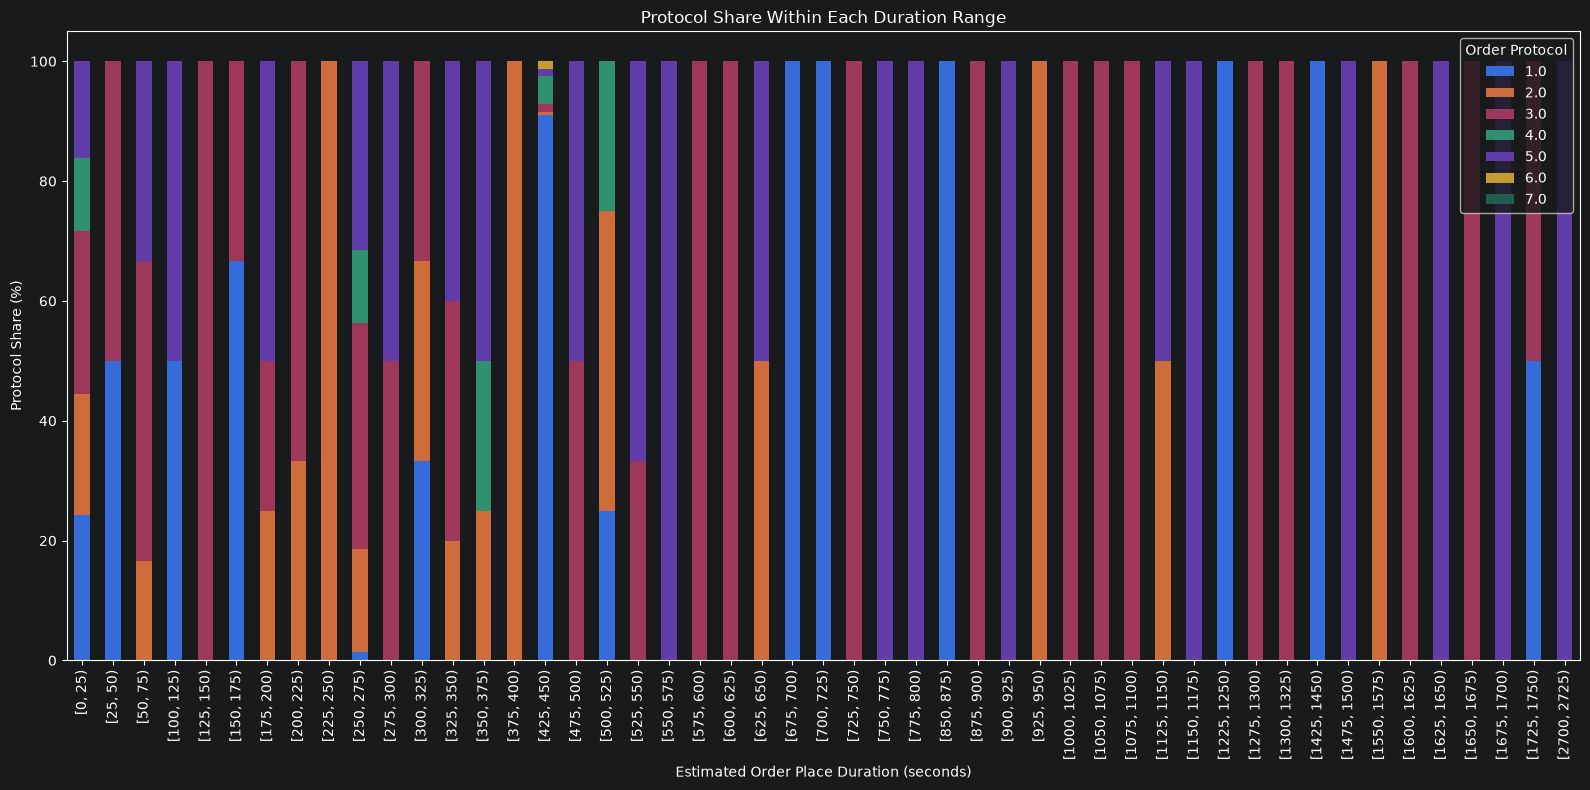

In [30]:
duration_protocol_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8)
)

plt.xlabel("Estimated Order Place Duration (seconds)")
plt.ylabel("Protocol Share (%)")
plt.title("Protocol Share Within Each Duration Range")
plt.legend(title="Order Protocol")

plt.tight_layout()
plt.show()

In [31]:
dominance = pd.DataFrame({
    "dominant_protocol": duration_protocol.idxmax(axis=1),
    "dominant_count": duration_protocol.max(axis=1),
    "total_orders": duration_protocol.sum(axis=1),
})

dominance["dominance_pct"] = (
    dominance["dominant_count"] / dominance["total_orders"] * 100
)

dominance

,dominant_protocol,dominant_count,total_orders,dominance_pct
duration_bin,,,,
"[0, 25)",3.0,27,99,27.272727
"[25, 50)",1.0,1,2,50.000000
"[50, 75)",3.0,3,6,50.000000
"[100, 125)",1.0,1,2,50.000000
"[125, 150)",3.0,1,1,100.000000
"[150, 175)",1.0,2,3,66.666667
"[175, 200)",5.0,2,4,50.000000
"[200, 225)",3.0,2,3,66.666667
"[225, 250)",2.0,1,1,100.000000


In [32]:
# Reproducibility
np.random.seed(42)

# Create 25-second bins
bins = np.arange(
    0,
    df["estimated_order_place_duration"].max() + 25,
    25
)

df["duration_bin"] = pd.cut(
    df["estimated_order_place_duration"],
    bins=bins,
    right=False
)

# Rows where protocol is known
known = df.dropna(subset=["order_protocol"])

# P(protocol | duration_bin)
protocol_probs = pd.crosstab(
    known["duration_bin"],
    known["order_protocol"],
    normalize="index"
)

# Fill missing protocols probabilistically
missing_mask = df["order_protocol"].isna()

for bin_value in df.loc[missing_mask, "duration_bin"].dropna().unique():

    mask = (
        missing_mask
        & (df["duration_bin"] == bin_value)
    )

    if bin_value in protocol_probs.index:

        probs = protocol_probs.loc[bin_value]

        protocols = probs.index.to_numpy()
        probabilities = probs.values

        df.loc[mask, "order_protocol"] = np.random.choice(
            protocols,
            size=mask.sum(),
            p=probabilities
        )

# Remove temporary bin column
df.drop(columns="duration_bin", inplace=True)

In [33]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 197421
Null Rows in market_id: 987
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 4760
Null Rows in order_protocol: 0
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16262
Null Rows in total_busy_dashers: 16262
Null Rows in total_outstanding_orders: 16262
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 526


In [34]:
store_market = (
    df.dropna(subset=["market_id"])
      .groupby("store_id")["market_id"]
      .nunique()
)

store_market.value_counts()

market_id
1    3825
2    1587
3     701
4     360
5     180
6      87
Name: count, dtype: int64

In [35]:
# --- Impute market_id using per-store mode ---

# Flag rows that will be imputed
df["market_id_imputed"] = df["market_id"].isna()

# Mode market_id per store, computed from known rows only
store_mode_market = (
    df.dropna(subset=["market_id"])
      .groupby("store_id")["market_id"]
      .agg(lambda x: x.mode().iloc[0])
)

# Map store -> mode market, fill only missing values
df["market_id"] = df["market_id"].fillna(df["store_id"].map(store_mode_market))

print(f"Remaining nulls in market_id: {df['market_id'].isnull().sum()}")

Remaining nulls in market_id: 3


In [36]:
store_market_dist = (
    df.dropna(subset=["market_id"])
      .groupby(["store_id", "market_id"])
      .size()
      .groupby(level=0)
      .transform(lambda x: x / x.sum())
)

store_market_confidence = (
    store_market_dist
    .groupby(level=0)
    .max()
)

imputed_rows = df["market_id_imputed"]

confidence = df.loc[imputed_rows, "store_id"].map(
    store_market_confidence
)

confidence.describe()

count    984.000000
mean       0.961349
std        0.032076
min        0.666667
25%        0.950444
50%        0.964157
75%        0.978864
max        1.000000
Name: store_id, dtype: float64

In [37]:
# Drop the 3 unresolvable rows (store has no other known market_id)
df = df.dropna(subset=["market_id"])

In [38]:
print(f"Total Rows: {len(df)}")
for col in df.columns:
    print(f"Null Rows in {col}: {df[col].isnull().sum()}")

Total Rows: 197418
Null Rows in market_id: 0
Null Rows in created_at: 0
Null Rows in actual_delivery_time: 0
Null Rows in store_id: 0
Null Rows in store_primary_category: 4759
Null Rows in order_protocol: 0
Null Rows in total_items: 0
Null Rows in subtotal: 0
Null Rows in num_distinct_items: 0
Null Rows in min_item_price: 0
Null Rows in max_item_price: 0
Null Rows in total_onshift_dashers: 16261
Null Rows in total_busy_dashers: 16261
Null Rows in total_outstanding_orders: 16261
Null Rows in estimated_order_place_duration: 0
Null Rows in estimated_store_to_consumer_driving_duration: 526
Null Rows in market_id_imputed: 0
